# Análise - Rating Books

Respondendo às perguntas:
1. Quais gêneros têm mais avaliações no total e melhores notas médias?
2. Quais livros são os mais bem avaliados dentro de cada gênero?
3. Quais autores se destacam (melhor nota média) dentro de cada gênero?
4. Quais os livros são mais caros?

In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

TABLEAU10 = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
             "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"]

sns.set_theme(style="white", rc={
    "font.size": 12,
    "axes.facecolor": "white",
    "axes.edgecolor": "#cccccc",
    "axes.grid": False,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "text.color": "#333333",
})

df = pd.read_csv("books_1.Best_Books_Ever.csv")
df["genres"] = df["genres"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df_exploded = df.explode("genres")

## 1. Gêneros com mais avaliações

In [2]:
genre_stats = df_exploded.groupby("genres").agg(
    total_ratings=("numRatings", "sum"),
    avg_rating=("rating", "mean"),
    book_count=("title", "nunique"),
).sort_values("total_ratings", ascending=False)

display("Gêneros com mais avaliações (TOP 15):")
display(genre_stats[["total_ratings", "avg_rating", "book_count"]].head(15))

'Gêneros com mais avaliações (TOP 15):'

,total_ratings,avg_rating,book_count
genres,,,
Fiction,798727913,3.968697,30081
Fantasy,397519302,4.015383,14328
Young Adult,335459161,3.987705,11362
Audiobook,333774204,3.992369,7204
Romance,324139718,3.988593,14527
Adult,291389824,3.977789,8016
Classics,290140609,4.014376,6796
Novels,246307896,3.900192,7724
Contemporary,239291663,3.930531,10139


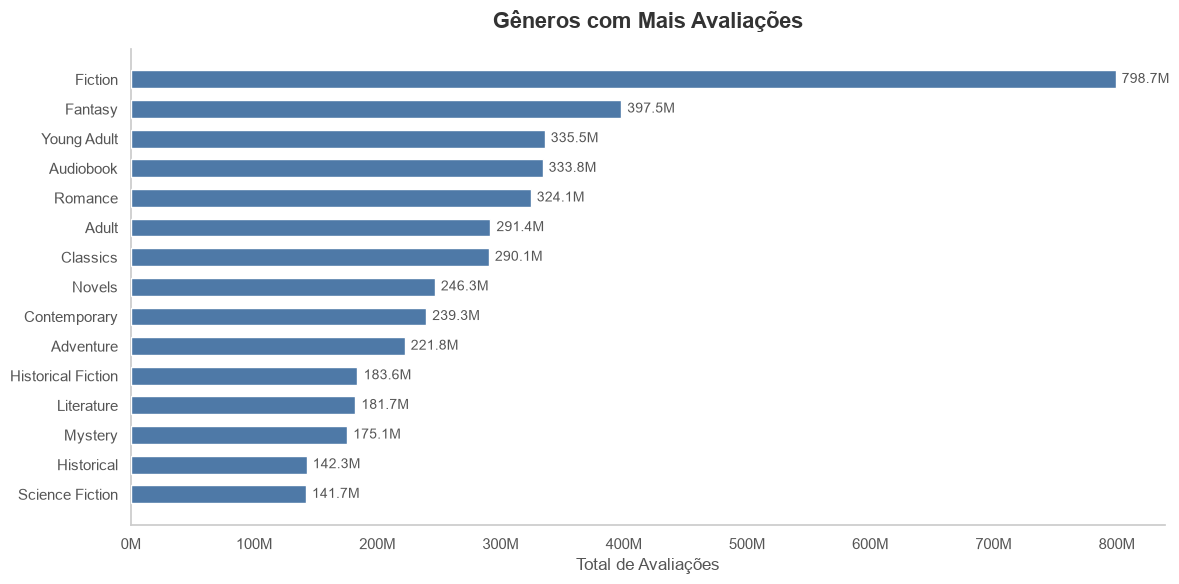

In [3]:
top_data = genre_stats.head(15).sort_values("total_ratings")

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_data)), top_data["total_ratings"].values,
               color=TABLEAU10[0], height=0.6, zorder=3)
ax.set_yticks(range(len(top_data)))
ax.set_yticklabels(top_data.index, fontsize=11)
ax.set_xlabel("Total de Avaliações", fontsize=12, color="#555555")
ax.set_title("Gêneros com Mais Avaliações", fontsize=16, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(axis="y", left=False)
ax.tick_params(axis="x", colors="#555555")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
for bar, val in zip(bars, top_data["total_ratings"]):
    ax.text(val + 5e6, bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=10, color="#555555")
plt.tight_layout()
plt.show()

## 1b. Gêneros com melhores notas médias

In [4]:
reliable = genre_stats[genre_stats["book_count"] >= 5].sort_values("avg_rating", ascending=False).head(15)

display("Gêneros com melhores notas médias (mín. 5 livros, TOP 15):")
display(reliable[["avg_rating", "total_ratings", "book_count"]])

'Gêneros com melhores notas médias (mín. 5 livros, TOP 15):'

,avg_rating,total_ratings,book_count
genres,,,
Baha I,4.625000,1588,6
Cartoon,4.474054,367823,37
Comic Strips,4.459322,716979,59
Lds Non Fiction,4.426552,161535,29
Scripture,4.425417,30108,24
Webcomic,4.400417,38137,24
Manhwa,4.344000,14935,10
Anti Racist,4.338261,799853,46
Divination,4.328000,23325,5


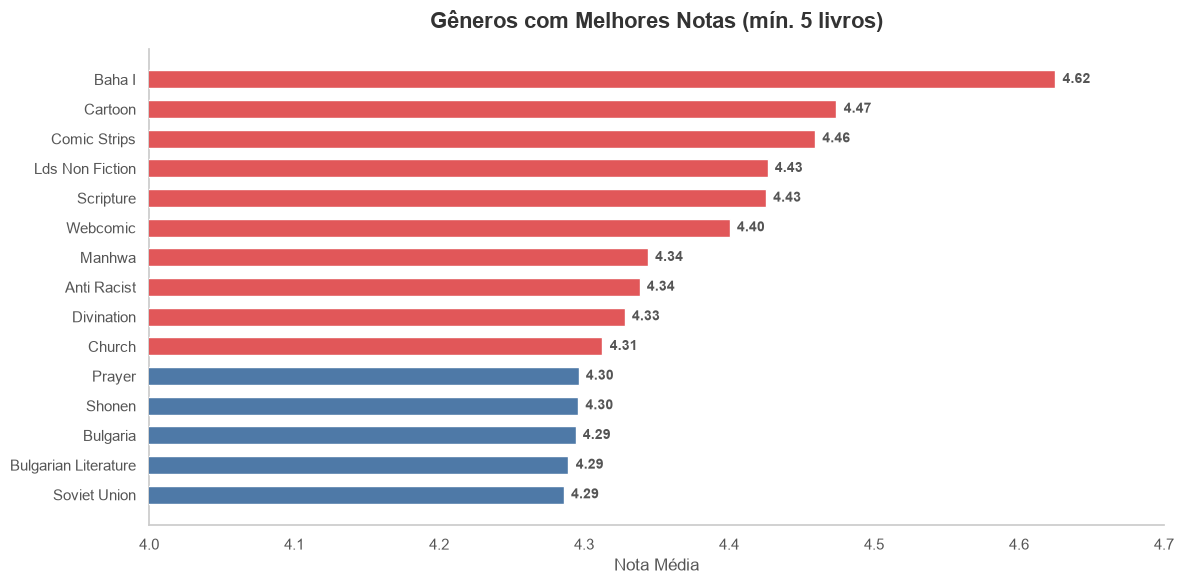

In [5]:
top_avg = reliable.sort_values("avg_rating")
colors_avg = [TABLEAU10[2] if v >= 4.3 else TABLEAU10[0] for v in top_avg["avg_rating"].values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_avg)), top_avg["avg_rating"].values,
               color=colors_avg, height=0.6, zorder=3)
ax.set_yticks(range(len(top_avg)))
ax.set_yticklabels(top_avg.index, fontsize=11)
ax.set_xlabel("Nota Média", fontsize=12, color="#555555")
ax.set_title("Gêneros com Melhores Notas (mín. 5 livros)", fontsize=16, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(axis="y", left=False)
ax.tick_params(axis="x", colors="#555555")
ax.set_xlim(4.0, 4.7)
for bar, val in zip(bars, top_avg["avg_rating"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va="center", fontsize=10, color="#555555", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Livros mais bem avaliados dentro de cada gênero

In [6]:
df_exploded["rank_in_genre"] = df_exploded.groupby("genres")["rating"].rank("dense", ascending=False)
top3 = df_exploded[df_exploded["rank_in_genre"] <= 3][["genres", "title", "author", "rating"]].drop_duplicates()
display("TOP 3 livros por gênero (amostra):")
display(top3.groupby("genres").head(3).head(30))

'TOP 3 livros por gênero (amostra):'

,genres,title,author,rating
121,Counting,The Very Hungry Caterpillar,Eric Carle,4.30
172,Angels,Clockwork Princess,Cassandra Clare (Goodreads Author),4.57
234,Banned Books,A Light in the Attic,Shel Silverstein,4.34
256,Comics,The Complete Calvin and Hobbes,Bill Watterson,4.82
256,Graphic Novels,The Complete Calvin and Hobbes,Bill Watterson,4.82
256,Comedy,The Complete Calvin and Hobbes,Bill Watterson,4.82
256,Classics,The Complete Calvin and Hobbes,Bill Watterson,4.82
256,Graphic Novels Comics,The Complete Calvin and Hobbes,Bill Watterson,4.82
256,Comic Strips,The Complete Calvin and Hobbes,Bill Watterson,4.82
256,Comic Book,The Complete Calvin and Hobbes,Bill Watterson,4.82


## 3. Autores que se destacam por gênero

In [7]:
author_genre = df_exploded.groupby(["genres", "author"]).agg(
    avg_rating=("rating", "mean"),
    book_count=("title", "nunique"),
).reset_index()
author_genre = author_genre[author_genre["book_count"] >= 2]
top_authors = author_genre.loc[author_genre.groupby("genres")["avg_rating"].idxmax()]
top_authors = top_authors.sort_values("avg_rating", ascending=False).head(20)

display("Autores com melhor nota média por gênero (mín. 2 livros, TOP 20):")
display(top_authors[["genres", "author", "avg_rating", "book_count"]])

'Autores com melhor nota média por gênero (mín. 2 livros, TOP 20):'

,genres,author,avg_rating,book_count
77048,Fantasy,Elias Zapple (Goodreads Author),4.857500,4
34546,Business,Maria Johnsen (Goodreads Author),4.855000,4
121985,Humor,Elias Zapple (Goodreads Author),4.850000,5
91016,Fiction,Kenneth Thomas (Goodreads Author),4.835000,2
67750,Dystopia,Kenneth Thomas (Goodreads Author),4.835000,2
33353,British Literature,Kenneth Thomas (Goodreads Author),4.835000,2
202556,Science Fiction,Kenneth Thomas (Goodreads Author),4.835000,2
150258,Mystery,Elias Zapple (Goodreads Author),4.835000,2
62645,Cyberpunk,Kenneth Thomas (Goodreads Author),4.835000,2
65083,Dogs,Elias Zapple (Goodreads Author),4.835000,2


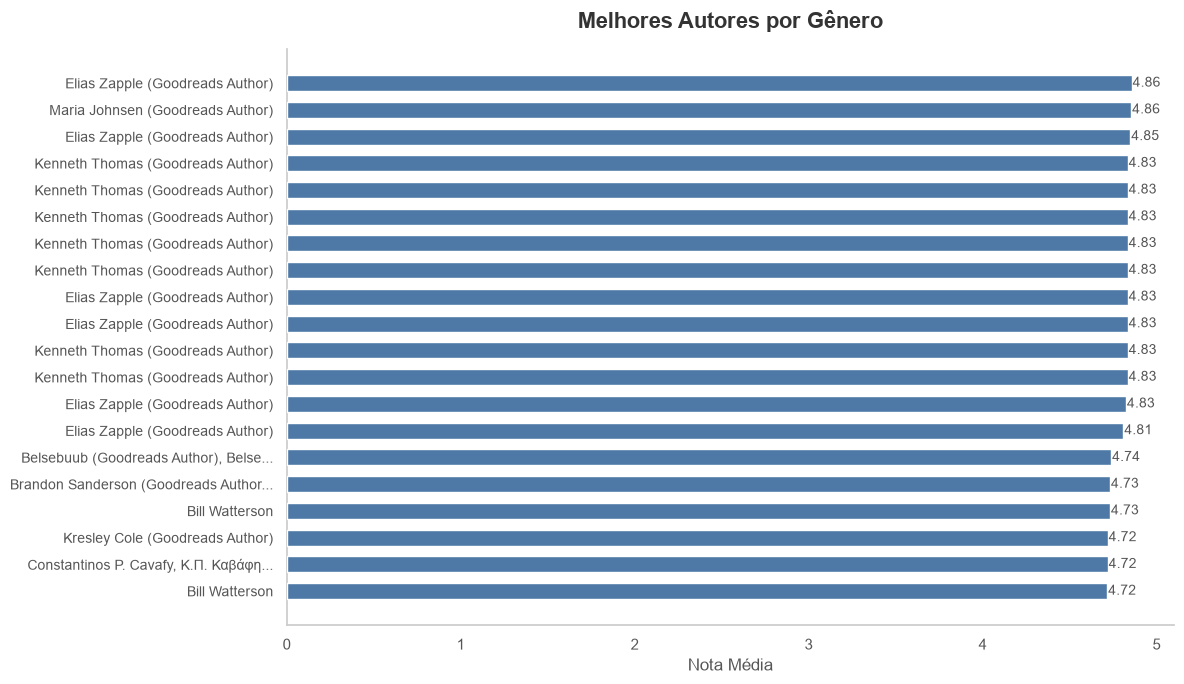

In [8]:
top_authors_sorted = top_authors.sort_values("avg_rating").reset_index(drop=True).copy()
mask = top_authors_sorted["author"].str.len() > 35
top_authors_sorted["label"] = np.where(
    mask,
    top_authors_sorted["author"].str[:35] + "...",
    top_authors_sorted["author"].str[:35]
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top_authors_sorted)), top_authors_sorted["avg_rating"].values,
               color=TABLEAU10[0], height=0.6, zorder=3)
ax.set_yticks(range(len(top_authors_sorted)))
ax.set_yticklabels(top_authors_sorted["label"].values, fontsize=10)
ax.set_xlabel("Nota Média", fontsize=12, color="#555555")
ax.set_title("Melhores Autores por Gênero", fontsize=16, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(axis="y", left=False)
ax.tick_params(axis="x", colors="#555555")
for bar, val in zip(bars, top_authors_sorted["avg_rating"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=10, color="#555555")
plt.tight_layout()
plt.show()

## 4. Livros mais caros

In [9]:
expensive = df.dropna(subset=["price"]).nlargest(20, "price")
display("Livros mais caros (TOP 20):")
display(expensive[["title", "author", "price", "rating", "numRatings"]])

'Livros mais caros (TOP 20):'

,title,author,price,rating,numRatings
32984,I See by My Outfit,Peter S. Beagle (Goodreads Author),898.64,4.11,379
29560,Margin of Safety: Risk-Averse Value Investing ...,Seth A. Klarman,867.05,4.34,5404
51332,V/Crying of Lot 49/Gravity's Rainbow,Thomas Pynchon,811.04,4.41,91
36503,"Men's Garments, 1830-1900: Guide to Pattern Cu...",R.I. Davis,796.14,4.42,19
11517,Viper's Creed,T.L. Shreffler (Goodreads Author),791.43,4.29,2650
18834,Progeny,Patrick C. Greene (Goodreads Author),777.35,3.72,374
5808,Children of Time,Adrian Tchaikovsky (Goodreads Author),711.55,4.28,58124
17663,The Oxford English Dictionary (20 Volume Set),"John Andrew Simpson (Editor), E.S.C. Weiner (E...",653.73,4.72,215
19513,My Year in Oman: An American Experience in Ara...,Matthew D. Heines (Goodreads Author),636.27,3.45,11
47920,Revolutionary Letters,Diane di Prima,631.99,4.29,322


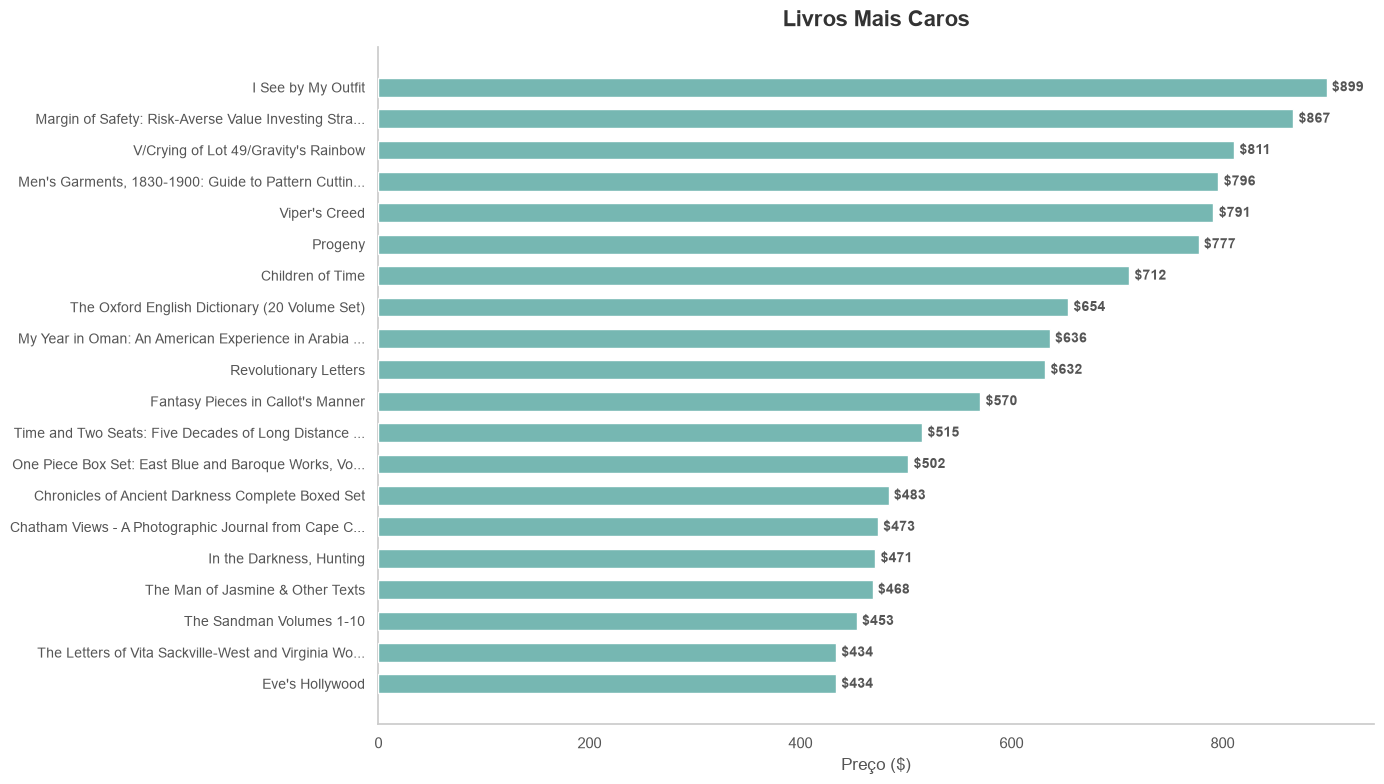

In [10]:
top_expensive = expensive.sort_values("price").reset_index(drop=True).copy()
mask_price = top_expensive["title"].str.len() > 50
top_expensive["short_title"] = np.where(
    mask_price,
    top_expensive["title"].str[:50] + "...",
    top_expensive["title"].str[:50]
)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top_expensive)), top_expensive["price"].values,
               color=TABLEAU10[3], height=0.6, zorder=3)
ax.set_yticks(range(len(top_expensive)))
ax.set_yticklabels(top_expensive["short_title"].values, fontsize=10)
ax.set_xlabel("Preço ($)", fontsize=12, color="#555555")
ax.set_title("Livros Mais Caros", fontsize=16, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(axis="y", left=False)
ax.tick_params(axis="x", colors="#555555")
for bar, val in zip(bars, top_expensive["price"]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f"${val:.0f}", va="center", fontsize=10, color="#555555", fontweight="bold")
plt.tight_layout()
plt.show()

## Extra: Preço vs Nota vs Avaliações

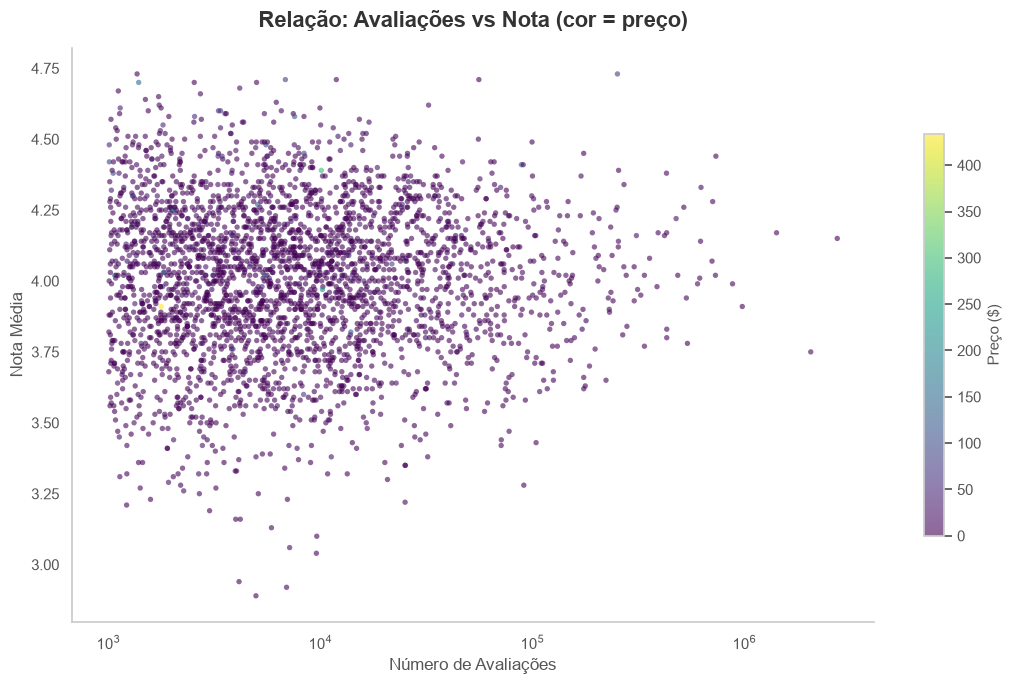

In [11]:
sample = df[df["numRatings"] > 1000].sample(min(3000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    sample["numRatings"].values, sample["rating"].values,
    c=sample["price"].fillna(0).values, alpha=0.6, s=15,
    cmap="viridis", edgecolors="none", zorder=3
)
ax.set_xscale("log")
ax.set_xlabel("Número de Avaliações", fontsize=12, color="#555555")
ax.set_ylabel("Nota Média", fontsize=12, color="#555555")
ax.set_title("Relação: Avaliações vs Nota (cor = preço)", fontsize=16, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(colors="#555555")
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Preço ($)", fontsize=11, color="#555555")
cbar.ax.tick_params(colors="#555555")
plt.tight_layout()
plt.show()

In [12]:
livros_com_preco = df["price"].notna().sum()
total_livros = len(df)
print(f"Livros com preço: {livros_com_preco} de {total_livros} ({100*livros_com_preco/total_livros:.1f}%)")

Livros com preço: 38101 de 52478 (72.6%)
